# Data Pipeline - (Machine) Learning from Disaster

In this notebook, you will implement a full machine learning workflow, from preprocessing to model evaluation. 
The dataset we use is a famous one: [the Titanic dataset](https://www.kaggle.com/competitions/titanic/data) (yes, the big boat that sank...).

The idea is simple: use ML to predict which passengers **survived** the Titanic shipwreck. The dataset is quite simple to understand but presents some real-world challenges (e.g., missing values). The explanation of the dataset is available at the link above.

## Goals
The *first* and most important goal of this lab is to guide you towards a higher level of autonomy when dealing with ML problems, in particular, classification problems (and in the later part, optionally, you will deal with a regression problem). 

The *second* goal is to get an understanding of the Support Vector Machine (SVM) algorithm, which is a (relatively) simple but powerful ML algorithm.

This document provides just the skeleton of your program, reminding you of the main steps to be accomplished.
At the end of this lab, you will be able to:
- Work on a jupyter notebook for a ML problem.
- Develop a full Machine Learning pipeline starting from a skeleton.
- Perform data exploration and data preparation
- Train, tune and **properly** evaluate ML models.

## Structure
This notebook is divided into 3 main parts:
1. **Data Exploration**: where you will explore the dataset using the Pandas library.
2. **Data Preparation**: where you will preprocess the data to be used in the ML model.
3. **Modeling, fine-tuning and evaluation**: where you will train, tune and evaluate the ML models.

## 1 Data Exploration

### 1.1 Read the data
We dowloaded the dataset for you. You will find the .csv file in the `data` folder.

In [ ]:
# some useful imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# read csv from data folder
df = pd.read_csv('data/train.csv')

In the cell above, we read and stored the data in a pandas *dataframe*.
A dataframe is a 2-dimensional labeled data structure with columns of potentially different types.
You can think of it like a spreadsheet or SQL table, or a dictionary of Series objects.

In the next cells, we will start exploring the data while starting to learn how to use the most important functions of the pandas library.

### 1.2 Have a look to the data

In Machine Learning, the **first** thing we want to do is to look at the data. *Always*.
This page https://www.kaggle.com/competitions/titanic/data contains the so-called "metadata".
Metadata refers to data that provides information about other data. It describes various aspects of data, such as its origin, format, structure, and context, making it easier to understand, manage, and use. Metadata can be crucial for organizing, locating, and interpreting different types of information within a dataset or system.

In the metadata description you can find information about the data we are going to use. Give it a look.

**Question**:
Checking the data card of the model, how many features are there? How many labels? (or target?). In other terms, if you would like to put this data in a tabel-like structure, how many rows would you have? How many columns?

**Answer**:
- Columns: 12
- Features: 11
- Labels: 1 (survival)
- Rows: 891

Let's see if the data are consistent with the metadata.
To do that, we will use our first pandas function: `head()`.

In [3]:
# we print the first 5 rows of the dataframe
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# we print the first 10 rows of the dataframe
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
# we also print the last 5 rows of the dataframe
df.tail()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


To get a better understanding of the data, we can also print the shape of the dataframe (i.e., number of rows, columns, etc.), the column names and data types.
Finally, we can also print the descriptive statistics of the data.
This is done using the functions `shape`, `info` and `describe`, respectively.

In [6]:
# we print the shape of the dataframe
df.shape



(891, 12)

In [7]:
# we print the column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# we print the descriptive statistics of the dataframe
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Questions**:
1. Is the data consistent with the metadata?
2. Which columns are features? Which columns are labels? (or target?)
3. Among the features, there is one that is not correlated with any possible useful prediction. Which one and why?
4. What is the mean of the target?
5. Why not all columns are present in the descriptive statistics?
6. Is the dataset in your opinion "balanced" with respect to the column `Survived` (hint: try the method `df['Survived'].value_counts()`) ? If not, can this be a problem?


**Answer**:
1. Yes, the data is consistent with the metadata. With a tiny difference: in the website, the variable `Survived` is called `Survival`.
2. Features: all columns except `Survived` are features.
3. `PassengerId` is not correlated with any possible useful prediction. It is just an identifier.
4. The mean of the target is 0.383838.
5. Not all columns are present in the descriptive statistics because the function `describe` only works with numerical columns. There is no point in calculating the mean, standard deviation, etc. of non-numerical columns (e.g., the name of the passengers).
6. The dataset is not balanced with respect to the column `Survived`. The mean of the target is 0.383838, which means that only 38.38% of the passengers survived. This is a common issue in classification problems, where the classes are not balanced.

In [9]:
# we print the value counts of the column Survived to check for imbalance
df['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

### 1.3 Missing data
In this subsection we check if our dataset is complete.

In [10]:
# we print the number of missing values in the dataframe
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
# we check the percentage of missing values in the dataframe
df.isnull().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

**Questions**:
- Are there missing values in the dataset?
- If yes, how many missing values are there in each column?
- Are there missing values in the target column? If yes, how many?

NOTES: Knowing the purcentage of missing values and their type (i.e., numerical, categorical, etc.) is crucial for deciding how to handle them.

**Answers**:
- Yes, there are missing values in the dataset.
- The columns `Age`, `Cabin` and `Embarked` have missing values. The column `Cabin` has the highest number of missing values. They are so high that we may consider dropping this column (spoiler: we will).
- There are no missing values in the target column. If that was the case, we would have to drop the rows with missing values in the target column.

### 1.4 Correlation analysis
In this subsection, we check the correlation among features and between features and the target. We will plot a correlation matrix and a heatmap.

NOTE: For simplicity, we will only consider numerical features. We could also consider categorical features by converting them to numerical ones (e.g., using one-hot encoding, see next section).

In [12]:
# list of numerical variables
numerical_features = ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# list of categorical variables
categorical_features = ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [13]:
# we select the numerical columns 

df_numerical = df[numerical_features]

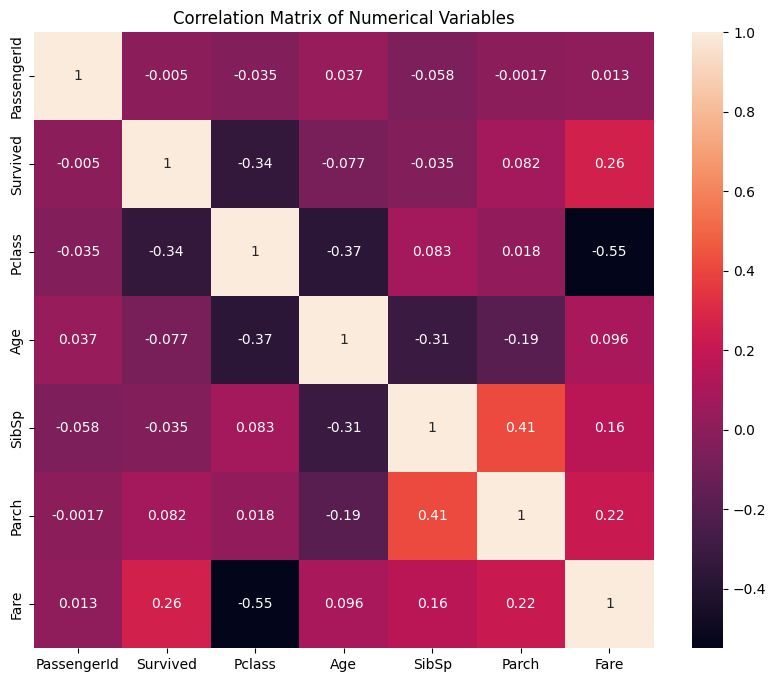

In [14]:
# we plot the correlation matrix of the numerical variables (it can take some time, depending on the size of the data)
import seaborn as sns

plt.figure(figsize=(10, 8))
correlation_matrix = df_numerical.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


**Questions**:
1. What is the most correlated feature with the target `Survived`? What does it means?
2. What is the less correlated feature with the target `Survived`? Is that a surprise?
3. What is the most correlated feature with the feature `Pclass`?
4. Is it good to have highly correlated features in the dataset? Why?
5. What is the meaning of a negative correlation?
6. What is the meaning of high correlation between a feature and the target?

**Answers**:
1. The most correlated feature with the target `Survived` is `Pclass`. It means that the class of the passenger is highly correlated with the survival rate. Sadly, this is not a surprise, as the class of the passenger is a good indicator of the social status of the passenger, which can be related to the survival rate.
2. The less correlated feature is PassengerId. This is not a surprise, as this is just an identifier.
3. The most correlated feature with the feature `Pclass` is `Fare`. Of course: the fare is related to the class of the passenger.
4. It is not good to have highly correlated features (among them) in the dataset. This is because highly correlated features can introduce multicollinearity (i.e., multiple features bring the same information, they are redoundant) in the dataset, which can lead to overfitting. In this case, we could even consider dropping one of the highly correlated features.
5. A negative correlation means that the two variables are inversely related. When one variable increases, the other variable decreases.
6. A high correlation between a feature and the target means that the feature is a good predictor of the target. This is what we want in a classification/regression problem.

### Extra - Getting used to pandas

This is not part of the usal ML pipeline, but it is important to get used to pandas. In the previous cells, we learned how to read data from a csv file and how to get a first look at the data.

In this subsection, we will practice some pandas commands that will help us in the next sections and labs.
In particular, we will learn how to select columns and rows from a dataframe and how to filter data.

#### E.1 Selecting columns using columns names

In [15]:
# we select the column 'Ticket' and store it in a variable called ticket;
# ticket is a pandas series (you can think of it as a 1-dimensional array)
ticket = df['Ticket']

# we print the first 5 rows of the air_temperature variable
ticket.head()

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: object

In the previous example, we selected a column from the dataframe.
We can now try to select multiple columns from the dataframe.

In [16]:
# we select the columns 'Ticket' and 'Fare' and store them in a variable called ticket_and_fare;
# ticket_and_fare is a pandas dataframe (you can think of it as a 2-dimensional array)
ticket_and_fare = df[['Ticket', 'Fare']]

# we print the first 5 rows of the temperatures variable
ticket_and_fare.head()


,Ticket,Fare
0,A/5 21171,7.2500
1,PC 17599,71.2833
2,STON/O2. 3101282,7.9250
3,113803,53.1000
4,373450,8.0500


#### E.2 Selecting rows and columns using their index (iloc)
We can also select rows from the dataframe.
`iloc` is a method that allows us to select rows from the dataframe. It returns a row as a pandas series or a dataframe (if more than one raw are selected).

In [17]:
# we select the first row of the dataframe
df.iloc[0]


PassengerId                          1
Survived                             0
Pclass                               3
Name           Braund, Mr. Owen Harris
Sex                               male
Age                               22.0
SibSp                                1
Parch                                0
Ticket                       A/5 21171
Fare                              7.25
Cabin                              NaN
Embarked                             S
Name: 0, dtype: object

In [18]:
# we select multiple rows from the dataframe
df.iloc[[0, 1, 2]]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


Like lists, numpy arrays, etc. it is possible to "slice" pandas series and dataframes. We use the method `.iloc()` Here are some examples:

In [19]:
# we select the first 5 rows of the dataframe
df.iloc[:5]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
# we select the last 5 rows of the dataframe
df.iloc[-5:]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [21]:
# we select the rows from index 5 to index 10
df.iloc[5:10]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


With `iloc`, we can also select columns from the dataframe. Here are some examples:

In [22]:
# we select the columns from index 0 to index 2
df.iloc[:, 0:2]

,PassengerId,Survived
0,1,0
1,2,1
2,3,1
3,4,1
4,5,0
...,...,...
886,887,0
887,888,1
888,889,0
889,890,1


In [23]:
# we select the rows from index 5 to index 10 and the columns from index 0 to index 2
df.iloc[5:10, 0:2]

,PassengerId,Survived
5,6,0
6,7,0
7,8,0
8,9,1
9,10,1


**Question**:
1. Select the first 5 rows of the dataframe and the columns from index 0 to index 2.
2. Select the last 5 rows of the dataframe and the columns from index 0 to index 2.
3. Select the rows from index 15 to index 25 and the columns from index 2 to index 3.

*Suggestion: do not hesitate to add multiple cells to answer the question.*

**Answers**:

In [24]:
# 1. Select the first 5 rows of the dataframe and the columns from index 0 to index 2.
df.iloc[:5, 0:2]

,PassengerId,Survived
0,1,0
1,2,1
2,3,1
3,4,1
4,5,0


In [25]:
# 2. Select the last 5 rows of the dataframe and the columns from index 1 to index 3.
df.iloc[-5:, 1:3]

,Survived,Pclass
886,0,2
887,1,1
888,0,3
889,1,1
890,0,3


In [26]:
# 3. Select the first 5 rows of the dataframe and the 'Ticket' and 'Fare' columns.
df.iloc[:5, [0, 2]]

,PassengerId,Pclass
0,1,3
1,2,1
2,3,3
3,4,1
4,5,3


#### E.3 Selecting rows and columns using their labels (a.k.a. name) (loc)

`iloc()` is not the only method that allows us to select rows from a dataframe.
We can also use `loc()`. The difference between `iloc()` and `loc()` is that `iloc()` selects rows by index and `loc()` selects rows by label. Here are some examples:

In [27]:
# we select the first row of the dataframe
df.loc[0]

# we select multiple rows from the dataframe
df.loc[[0, 1, 2]]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


As you can see there is not much of a difference when working with *rows*, since rows are *usually* indexed with numbers.
However, when working with **columns**, `loc()` is arguably more useful (and readable) than `iloc()`.

In [28]:
# we select the column 'SibSp' using loc
df.loc[:, 'SibSp']

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    1
889    0
890    0
Name: SibSp, Length: 891, dtype: int64

In [29]:
# we select the columns 'SibSp' and 'Sex' using loc
df.loc[:, ['SibSp', 'Sex']]

,SibSp,Sex
0,1,male
1,1,female
2,0,female
3,1,female
4,0,male
...,...,...
886,0,male
887,0,female
888,1,female
889,0,male


**Questions**:
1. Select the first 5 rows of the dataframe and the column `Ticket` using loc.
2. Select 10 rows starting at the index 11 for the columns`Fare` and `Sex` using loc.

**Answer**:

In [30]:
# 1. Select the first 5 rows of the dataframe and the column `Ticket` using loc.
df.loc[:4, 'Ticket']

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: object

In [31]:
# 2. Select 10 rows starting at the index 11 for the columns`Fare` and `Sex` using loc.
df.loc[11:21, ['Fare', 'Sex']]


,Fare,Sex
11,26.5500,female
12,8.0500,male
13,31.2750,male
14,7.8542,female
15,16.0000,female
16,29.1250,male
17,13.0000,male
18,18.0000,female
19,7.2250,female
20,26.0000,male


**NOTE 1**:  test1 = df.loc[:, 'Fare'] is equivalent to test2 = df['Fare']

In [32]:
# 3. Is **test1** = df.loc[:, 'Fare'] equivalent to **test2** = df['Fare']? 
test1 = df.loc[:, 'Fare']
test2 = df['Fare']

print(test1.equals(test2)) # True

True


**NOTE 2**: by default we are **NOT** creating new dataframes. Dataframes maybe very big, copying them will take too much resources. In the previous exemple, `test1` and `test2` are pointing at the *same* address in the memory. In other terms, by default, we work with "views" on the same dataset.
You can check this with the `is` operator:

In [33]:
if test1 is test2:
    print("yup, told ya, the two variables point to the same object in memory")

yup, told ya, the two variables point to the same object in memory


**For the sake of completeness**: you may need to copy a dataframe. If you want to duplicate a dataframe, you have to use the method `.copy()`, see the [official documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.copy.html) for more information. 

#### E.4 Filtering data
Last but not least, with pandas we can also easily filter data. Filtering data means selecting rows that satisfy a certain condition.

In [34]:
# we select the rows where the column 'Sex' is equal to 'male' (i.e., we only select male passengers)
df[df['Sex'] == 'male']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [35]:
# we select the rows where the column 'Pclass' is equal to 2 (i.e, we select the passenger travelling in second class)
df[df['Pclass'] == 2]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
20,21,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0000,NaN,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
...,...,...,...,...,...,...,...,...,...,...,...,...
866,867,1,2,"Duran y More, Miss. Asuncion",female,27.0,1,0,SC/PARIS 2149,13.8583,NaN,C
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S


**Questions**:
1. Select the passengers travelling in 3rd class.
2. Select the passengers older than 18
3. (hard) Select the *famale* passengers with strinctly more than 1 parent / children aboard the Titanic

**Answer**:

In [36]:
# 1. Select the passengers travelling in 3rd class.
df[df['Pclass'] == 3]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [37]:
# 2. Select the passengers older than 18 (18 included).
df[df['Age'] >= 18]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [38]:
# 3. Select the famale passengers with strinctly more than 1 parent / children aboard the Titanic

df[(df['Sex'] == 'female') & (df['Parch'] > 1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
25,26,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.0,1,2,SC/Paris 2123,41.5792,NaN,C
58,59,1,2,"West, Miss. Constance Mirium",female,5.0,1,2,C.A. 34651,27.7500,NaN,S
68,69,1,3,"Andersson, Miss. Erna Alexandra",female,17.0,4,2,3101281,7.9250,NaN,S
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9000,NaN,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.2750,NaN,S
136,137,1,1,"Newsom, Miss. Helen Monypeny",female,19.0,0,2,11752,26.2833,D47,S
140,141,0,3,"Boulos, Mrs. Joseph (Sultana)",female,NaN,0,2,2678,15.2458,NaN,C


### 1.3 Conclusion Section 1
In this Section, we learned how to read data from a csv file and how to get a look at the data using the Pandas library. 
We also learned how to select columns and rows from a dataframe using the Pandas library and how to filter data using the Pandas library.

Today, Pandas is almost ubiquitous in machine learning when coding in Python. If the methods we’ve covered so far aren’t yet clear to you, don’t worry—it will become easier as you practice these techniques.

In the next secgtion, we will learn how to prepare the data for the training using another famous library: **Scikit-learn**.

---

## 2. Data preparation and introduction to Scikit-learn

In this second notebook, our primary emphasis will be on data preparation. This involves the essential steps of dividing the dataset into a *training set* and a *test set*, along with gaining insights into best practices for addressing specific issues or characteristics within our data. These characteristics may include:

- Features with varying scales
- The intermixing of numerical features (e.g., `Age`) and categorical features (e.g., `Sex`)
- Handling missing values

To tackle these challenges, we will use [Scikit-learn](https://scikit-learn.org/stable/). Scikit-learn, also known as sklearn, is an open-source machine learning library for the Python programming language. It is built on NumPy, SciPy, and Matplotlib, and it provides simple and efficient tools for data analysis and modeling. Scikit-learn is designed to work with a variety of machine learning tasks, including classification, regression, clustering, dimensionality reduction, and more.

Scikit-learn is widely used in both academia and industry for its user-friendly interface, extensive documentation, and the wealth of tools it offers for building and evaluating machine learning models.


**Goals**

In this second Section, we will focus on data preparation. In particular, you will learn how to use the Scikit-learn library to:
- Split the data into training and test sets
- Impute missing values
- Scale and/or standardize the data
- Encode categorical features

Remember: all the insights used for data preparation (e.g., values and logic used for imputation, scaling, etc.) should be learned from the training set **only**. Then, the same approach should be applied to training and test set. This is crucial to avoid data leakage and to ensure that the model is trained and evaluated on the same data distribution.


### 2.1 Separate the labels from the features

In [39]:
# we print (again) the first rows of the dataframe (for recap and better visualization)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Checking the columns, and with the information we got drom the Data Exploration section, we separate the columns into multiple lists:
- useless_columns: columns that are not useful for the model (e.g., `PassengerId`)
- numerical_columns: columns that are numerical (e.g., `Age`, `Fare`)
- categorical_columns: columns that are categorical (e.g., `Sex`, `Embarked`)
- target_column: the column we want to predict (e.g., `Survived`)

In [40]:
# Below, we also remove the "name" column. However, with an appropriate feature engineering,
# we could extract useful information from the name column such as the title
# (not only Mr., Mrs., Miss, but also Dr., Col., etc. which may or may not be correlated to an higher suvival rate)
usless_columns = ['PassengerId', 'Name', 'Ticket', 'Cabin'] 

# Target variable(s), in this case, only one
target = ['Survived']

# list of numerical variables
numerical_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# list of categorical variables
categorical_features = ['Sex', 'Embarked']


#NOTE: be sure that a column is not in more than one list and that all columns are in one of the lists

Before splitting the data into *training* and *test sets*, we need to separate the *labels* from the *features*. It is of **paramount importance** not providing the labels to the model during training!

This is the *noobest* mistake you can do in ML. It is like providing a test with the solutions: the model will learn the right solution "by heart" without actually understanding the data. Then, when you will provide new data, with no solution... good luck with that!

NOTES:
- In ML, the letter `X` usually indicates the features and `y` the labels. Here, we will use `X` and `y` to store the features and labels, respectively. We can do this first separation by using the `drop()` method of the Pandas library.
- the `drop()` method returns a **copy** of the dataframe with the specified columns removed. The `drop()` method does not change the original dataframe.
- since we are dropping columns, we will also drop usless columns (e.g., `PassengerId`). We will also drop the column `Cabin` because it has too many missing values (which was a precious insight from the Data Exploration section).


In [41]:
# we select the target to create our target variable y
y = df[target]

# we drop the target from the dataframe to create our features X
X = df.drop(target, axis=1)

In [42]:
# we print the first 5 rows of the features
X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [43]:
# we print the first 5 rows of the labels
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


From the insights that we got in the previous section, we drop the features that we think are not useful for our analysis.

In [44]:
# we drop the columns in the useless_columns list from the features
X = X.drop(usless_columns, axis=1)

In [45]:
# we print the first 10 rows of the features
X.head(10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
5,3,male,NaN,0,0,8.4583,Q
6,1,male,54.0,0,0,51.8625,S
7,3,male,2.0,3,1,21.0750,S
8,3,female,27.0,0,2,11.1333,S
9,2,female,14.0,1,0,30.0708,C


NOTEs:
- there is a missing value in the raw 5 for the column `Age`.
- now that we splitted the data into features and labels, we need to be careful in the next steps. Some methods require shuffling the data: if you change the order of the features, you will have to change the order of the labels accordingly!

### 2.2 Split the data into training and test sets

It is now time to actually split the data into "Training" and "Test" set. Remember: the test set will only be used for testing our model. NO learning should use these data. Once splitted, it is like these data do not exist for you until the final evaluation step. 

NOTE: if your data is already splitted into training and test sets, you can simply load them in the right variables.

In [46]:
# from the sklearn library we import the function to split the data into training and test sets
from sklearn.model_selection import train_test_split

# we split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # random_state is fixed for reproducibility. Do not change it.

In [47]:
# we check the shape of the original dataset
print('The shape of the original dataset is:', df.shape)

# we check the shape of the training set (features)
print('The shape of the training set is:', X_train.shape)

# we check the shape of the test set (features)
print('The shape of the test set is:', X_test.shape)

# we check the shape of the training set (labels)
print('The shape of the training labels is:', y_train.shape)

# we check the shape of the test set (labels)
print('The shape of the test labels is:', y_test.shape)

The shape of the original dataset is: (891, 12)
The shape of the training set is: (712, 7)
The shape of the test set is: (179, 7)
The shape of the training labels is: (712, 1)
The shape of the test labels is: (179, 1)


**Questions**:
- What is the purpose of the `test_size` parameter?
- What is the purpose of the `random_state` parameter? Should I change this parameter to find the one that gives the best results?
- Do we need to shuffle the data? Why is it important to shuffle (or not) the data before splitting it? (Hint: check in the doc the default value of the `shuffle` parameter)

**Answers**: 
- The `test_size` parameter is the proportion of the dataset to include in the test split. For example, if `test_size=0.2`, the dataset will be split into 80% training and 20% test.
- The `random_state` parameter is the seed used by the random number generator. If you set `random_state` to a fixed number, you will always get the same split. This is useful for reproducibility. You should not change it once fixed. It is not a hyperparameter to tune.
- We need to shuffle the data. The default value of the `shuffle` parameter is `True`. Shuffling the data is important to avoid any ordering bias in the data. If the data is not shuffled, the model may learn the order of the data and not the data itself. This could be different if you work with time series (e.g. meteorological data, anomaly detection in time-related processes, etc.) where the order of the data is important (e.g., to detect a sudden change in the temperature, you need to know the previous temperature).


### 2.3 Impute missing values

In this section, we will learn how to impute missing values using the Scikit-learn library.

Imputation
- Definition: the process of replacing missing data with substituted values.
- Example: we have missing values about the "age" of some passengers. Instead of dropping the whole raw of data, we substitute the missing age value with the average value of the age in the trining set.
- Be aware:
    - This is a trade-off: we introduce a bias in the data instead of losing some information.
    - Depending on some factors such as the size of the original dataset, the amount of missing data, this can be a good or a bad idea. If you have a big dataset, losing some data is not a big deal. If you have a small dataset, losing some data can be a big deal.
    - Never impute missing values in the target (y). You should drop the rows with missing values in the target.

Missing values

Missing values are often represented as `NaN` (Not a Number) or `None`. In the code below, we use the `isnull()` method of the Pandas library to check if there are any missing values in the dataset. The `isnull()` method returns a dataframe of booleans that indicate whether or not a value is missing (`True`) or not missing (`False`).
Then, we use the `any()` method of the Pandas library to check if the dataframe contains any `True` values. If the dataframe contains any `True` values, then we know that there are missing values in the dataset.

**Note (again)**: remember to perform all these tests on the training set ***only***. Always consider as the test set **is not** available during the training phase.


In [ ]:
# Just for recap, we print again the missing values in the training set
# # we check if there are any missing values in the training set
missing_values_training_X = X_train.isnull()

# we check if test contains any True values
print(missing_values_training_X.any())

# alternatively, if you want to see the number of missing values per feature
# we check the percentage of missing values in the dataframe
print()
print(missing_values_training_X.mean() * 100 )

: 

In [49]:
# Just for recap, we print again the missing values in the training set
# # we check if there are any missing values in the training set
missing_values_training_y = y_train.isnull()

# we check if test contains any True values
print(missing_values_training_y.any())

# alternatively, if you want to see the number of missing values per feature
# we check the percentage of missing values in the dataframe
print()
print(missing_values_training_y.isnull().mean() * 100 )

Survived    False
dtype: bool

Survived    0.0
dtype: float64


As we already observed, there are missing values in the columns `Age`, and `Embarked` (we removed `Cabin`).

**Question**:
- Repeat the test above to check if there are any missing values in the test set.

In [50]:
# we repeat the test for the test set. In this case, we can expect the same missing values in the test set as in the training set.
# however, it is good practice to check it anyway (i.e., in some cases the test set may contain missing values that are not present in the training set)
missing_values_test_X = X_test.isnull()
print(missing_values_test_X.any())
print()
print(missing_values_test_X.isnull().mean() * 100 )


missing_values_test_y = y_train.isnull()
print(missing_values_test_y.any())
print()
print(missing_values_test_y.isnull().mean() * 100 )


Pclass      False
Sex         False
Age          True
SibSp       False
Parch       False
Fare        False
Embarked    False
dtype: bool

Pclass      0.0
Sex         0.0
Age         0.0
SibSp       0.0
Parch       0.0
Fare        0.0
Embarked    0.0
dtype: float64
Survived    False
dtype: bool

Survived    0.0
dtype: float64


Let us start with the imputation

Some algorithms are able to handle missing values without preprocessing. You can find a list of these algorithms [here](https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values). However, most algorithms are not designed to handle missing values. Therefore, we need to impute them before training the model. There are many ways to impute missing values.

Possible approaches:
1. Drop rows with missing values. If you have a lot of data, this could you best option.
2. Impute missing values with the "mean" or "median". This apporach is suitable for numerical features.
3. Impute missing values with the "mode" (i.e., the most frequent value).  This apporach is suitable for categorical features (computing the mean does not make sense).
4. Impute missing values using more advanced approaches (such as k-nn!)

As an exemple, we will see how to implement 2 and 3 using the Scikit-learn library. 

In our dataset, we have both numerical features (e.g., `Age`) and categorical features (e.g., `Embarked`) with missing values. We will need to deal with them separately.


In [ ]:
# we deal with the missing values in the numerical features

# we import the SimpleImputer class from the sklearn library
# we will use 'mean' as strategy to impute the missing values
from sklearn.impute import SimpleImputer

# we create an object of the SimpleImputer class
# we start by dealing with the numerical features
imputer = SimpleImputer(strategy='mean')

# we fit the imputer to the training set
imputer.fit(X_train[numerical_features])

# we transform the training set
train_set_imputed_num = imputer.transform(X_train[numerical_features])

# we transform the test set
# we use the same imputer that was fit on the training set
test_set_imputed_num = imputer.transform(X_test[numerical_features])

In [ ]:
# we deal with the missing values in the categorical features

# we import the SimpleImputer class from the sklearn library
# we will use 'most_frequent' as strategy to impute the missing values
from sklearn.impute import SimpleImputer

# we create an object of the SimpleImputer class
# we start by dealing with the categorical features
imputer = SimpleImputer(strategy='most_frequent')

# we fit the imputer to the training set
imputer.fit(X_train[categorical_features])

# we transform the training set
train_set_imputed_cat = imputer.transform(X_train[categorical_features])

# we transform the test set
# we use the same imputer that was fit on the training set
test_set_imputed_cat = imputer.transform(X_test[categorical_features])

We test again the data to see if there are still some missing values.

NOTE: the Scikit-learn `.transform()` method returns a numpy.ndarray not a data frame. To continue working with pandas we need to convert it back to a data frame. However, for the moment, we will keep it as a numpy array since also the next steps require numpy arrays.

In [53]:
# we print the first 10 rows of the training set (there are no more missing values in the sixth row)
train_set_imputed_num[:10]

array([[  1.        ,  45.5       ,   0.        ,   0.        ,
         28.5       ],
       [  2.        ,  23.        ,   0.        ,   0.        ,
         13.        ],
       [  3.        ,  32.        ,   0.        ,   0.        ,
          7.925     ],
       [  3.        ,  26.        ,   1.        ,   0.        ,
          7.8542    ],
       [  3.        ,   6.        ,   4.        ,   2.        ,
         31.275     ],
       [  1.        ,  24.        ,   0.        ,   1.        ,
        247.5208    ],
       [  1.        ,  45.        ,   0.        ,   0.        ,
         26.55      ],
       [  2.        ,  29.        ,   1.        ,   0.        ,
         27.7208    ],
       [  3.        ,  29.49884615,   0.        ,   0.        ,
          7.8958    ],
       [  1.        ,  29.49884615,   0.        ,   0.        ,
         35.5       ]])

#### Optional task
Scikit-lern offers more advanced imputers. For example, the `IterativeImputer` class models each feature with missing values as a function of other features, and uses that estimate for imputation.
The `KNNImputer` class imputes missing values using the k-Nearest Neighbors approach (yes, we can use ML to solve ML problems).
For more information on these and other classes, see the [Scikit-learn documentation](https://scikit-learn.org/stable/modules/impute.html#impute).

Try the `IterativeImputer` class and the `KNNImputer` class to impute the missing values in the training set. Then, check if there are any missing values in the training set.

### 2.4 Scale and/or standardize the data
Rescaling or standardizing the data is useful for many algorithms that suffers when features' scale changes (e.g., KNN, SVM, Neural Networks, etc.). Basically, this concerns all algorithms based on the distance between data points.
Other algorithms, such as Decision Trees, are not affected by the scale of the features.

In the code below, we use the `StandardScaler` class to scale and/or standardize the data. The `StandardScaler` class standardizes features by removing the mean and scaling to unit variance. The standard score of a sample `x` is calculated as: 

$$
z = (x - \mu) / \sigma
$$

where $\mu$ is the mean of the training samples and $\sigma$ is the standard deviation of the training samples.

In [54]:
# from the sklearn library we import the function to scale and/or standardize the data
from sklearn.preprocessing import StandardScaler # other options include MinMaxScaler, RobustScaler, etc.

# we create a StandardScaler object
scaler = StandardScaler()

# we fit the scaler to the training set
scaler.fit(train_set_imputed_num)
    
# we transform the training set
X_train_set_scaled = scaler.transform(train_set_imputed_num)

# we transform the test set
X_test_set_scaled = scaler.transform(test_set_imputed_num)

**Questions**:
- We only rescaled the numerical features. Why did we not rescale the categorical features?
- Compare the standardized values with the original values. Compute the mean (`np.average()`) and the standard deviation (`np.std()`) of the original and standardized values. What do you expect and what do you observe?

**Answers**:
- We did not rescale the categorical features because they are not numerical. Rescaling categorical features does not make sense. For example, if we have a categorical feature with values `['A', 'B', 'C']`, rescaling these values would not make sense. The values are not ordered, and the distance between them is not meaningful. However, Categorical features should be encoded before being used in the model.
- You should see that the standardized values have a mean of 0 and a standard deviation of 1.

In [55]:
# we print the average of the scaled training set
print(np.average(X_train_set_scaled, axis=0))

# we print the standard deviation of the scaled training set
print(np.std(X_train_set_scaled, axis=0))

[9.35581201e-17 1.50940434e-16 1.74641824e-17 2.24539488e-17
 5.36399888e-17]
[1. 1. 1. 1. 1.]


*As expected: the mean ~= 0, std ~= 1*

Scikit-learn provides a number of other classes for scaling and/or standardizing the data. For example, the `MinMaxScaler` class scales features to a given range, usually between 0 and 1. The `RobustScaler` class scales features using statistics that are robust to outliers. For more information on these and other classes, see the [Scikit-learn documentation](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing).

**Questions**:
- instead of using the `StandardScaler` class, use the `RobustScaler` class to scale and/or standardize the data. Then, print the first 5 rows of the scaled training set.
- What is the difference between the `StandardScaler` and the `RobustScaler`? When should you use one over the other?

**Answers**:
- The `StandardScaler` class standardizes features by removing the mean and scaling to unit variance. The `RobustScaler` class scales features using statistics that are robust to outliers. The `RobustScaler` class is more robust to outliers than the `StandardScaler` class. You should use the `RobustScaler` class when you have outliers in your data.


### 2.5 Encode categorical features
In the previous section, we saw how to scale and/or standardize the numerical features. In this section, we will learn how to encode the categorical features.

Some algorithms do not have any problem to deal with a mixed feature set (i.e., numerical and categorical features). However, other algorithms require that all the features are numerical. Therefore, we need to encode the categorical features before training the model.
Typically, distance-based algorithms (e.g., KNN, SVM, Neural Networks, etc.) require that all the features are numerical.
How could you compute the distance between a numerical feature and a categorical feature? It does not make sense, right? Therefore, we need to encode the categorical features before training the model.

There are many ways to encode categorical features. We use the `OneHotEncoder` class to encode the categorical features. The `OneHotEncoder` class encodes categorical features as a one-hot numeric array. A one-hot array is a binary matrix where each row has exactly one element set to 1 and all other elements set to 0.



In [56]:
# before encoding the categorical features, we convert the numpy arrays to dataframes. This is not necessary, but it makes the code more readable (it will help the encoder to generate the correct column names)
X_train_set_imputed_cat = pd.DataFrame(train_set_imputed_cat, columns=categorical_features)
X_test_set_imputed_cat = pd.DataFrame(test_set_imputed_cat, columns=categorical_features)

In [57]:
# we import the OneHotEncoder class from the sklearn library
from sklearn.preprocessing import OneHotEncoder

# we create an OrdinalEncoder object
encoder = OneHotEncoder(sparse_output=False) # we set sparse_output=False to get a 2D array

# we fit the encoder to the training set
encoder.fit(X_train_set_imputed_cat[categorical_features])

# we transform the training set
X_train_set_encoded = encoder.transform(X_train_set_imputed_cat[categorical_features])

# we transform the test set
X_test_set_encoded = encoder.transform(X_test_set_imputed_cat[categorical_features])

In [58]:
# we put the encoded data back into a dataframe. The encoder generates understandably named columns for us
X_train_set_encoded_df = pd.DataFrame(X_train_set_encoded, columns=encoder.get_feature_names_out(categorical_features))
X_test_set_encoded_df = pd.DataFrame(X_test_set_encoded, columns=encoder.get_feature_names_out(categorical_features))

# we print the first 5 rows of the encoded training set
X_train_set_encoded_df.head()

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0


**Question**:
- Other encoders exist such as the `OrdinalEncoder`. Explain the difference between the `OrdinalEncoder` and the `OneHotEncoder`.


**Answer**:

There is an important difference between the `OrdinalEncoder` and the `OneHotEncoder`. The `OrdinalEncoder` encodes categorical features as an integer array, whereas the `OneHotEncoder` encodes categorical features as a one-hot numeric array. This means that the `OrdinalEncoder` perform a sort of ranking of the elements in the categorical feature. For example, in our dataset, the `Type` feature has 3 categories: `M`, `L`, and `H`. The `OrdinalEncoder` will encode these categories as 0, 1, and 2, respectively. This implies that the `OrdinalEncoder` assumes an ordinal relationship between the categories. In other words, the `OrdinalEncoder` assumes that `M` is less than `L`, and `L` is less than `H`. This is not always the case. For example, if we had a categorical feature with the categories `red`, `green`, and `blue`, then it would not make sense to assume an ordinal relationship between these categories. In this case, we would use the `OneHotEncoder` to encode the categorical feature.

The `OneHotEncoder` encodes categorical features as a one-hot numeric array. This means that each category is encoded as a binary vector. For example, in our dataset, the `Type` feature has 3 categories: `M`, `L`, and `H`. The `OneHotEncoder` will encode these categories as `[1, 0, 0]`, `[0, 1, 0]`, and `[0, 0, 1]`, respectively. This implies that the `OneHotEncoder` does not assume an ordinal relationship between the categories.

For this reason, the `OneHotEncoder` **is usually preferred** over the `OrdinalEncoder` because it does not assume an ordinal relationship between the categories. However, the `OneHotEncoder` can only be used with categorical features that have a finite number of categories. In our dataset, the `Type` feature has only 3 categories (i.e., `M`, `L`, and `H`). Therefore, we can use the `OneHotEncoder` to encode the `Type` feature.

### 2.6. Encode the target (label)

Finally, in some cases, we need to encode the target (label) as well. Suppose you have to classify "apple", "banana", and "orange". You can encode them as 0, 1, and 2, respectively. This is useful when you have a classification problem with more than two classes. However, in our case, we have a binary classification problem (i.e., survived or not survived). Therefore, we do not need to encode the target. To get more information about encoding the target, see the [Scikit-learn documentation](https://scikit-learn.org/stable/modules/preprocessing_targets.html#preprocessing-targets).

### 2.7. Putting it all together

As a result of steps 5 and 6 we create sub-datasets of the original dataset. In particular, we have:
- `X_train_set_scaled`: the training set with scaled and/or standardized numerical features
- `X_test_set_scaled`: the test set with scaled and/or standardized numerical features
- `X_train_set_encoded`: the training set with encoded categorical features
- `X_test_set_encoded`: the test set with encoded categorical features
- `y_train_set_encoded`: the training labels with encoded categorical features
- `y_test_set_encoded`: the test labels with encoded categorical features
 
Before starting the training and the evaluation in the next section, we need to concatenate the scaled and/or standardized numerical features with the encoded categorical features (we want a pandas dataframe).  

In [59]:
# We put back the numerical data in a pandas dataframe (we already did it for the categorical data)
X_train_set_scaled = pd.DataFrame(X_train_set_scaled, columns=numerical_features)
X_test_set_scaled = pd.DataFrame(X_test_set_scaled, columns=numerical_features)

In [60]:
# we concatenate the numerical and categorical dataframes to get the final training and test sets
X_train_final = pd.concat([X_train_set_scaled, X_train_set_encoded_df], axis=1)
X_test_final = pd.concat([X_test_set_scaled, X_test_set_encoded_df], axis=1)

Let us do a sanity check to see if everything is ok.

We should have the same rows that we had in the original training. The columns number may have changed due to the encoding and dropping of the "usless_columns".

In [61]:
# we check the shape of the final training and test sets
print('The shape of the final training set is:', X_train_final.shape, 'and the shape of y training is:', y_train.shape)
print('The shape of the final test set is:', X_test_final.shape, 'and the shape of y test is:', y_test.shape)


The shape of the final training set is: (712, 10) and the shape of y training is: (712, 1)
The shape of the final test set is: (179, 10) and the shape of y test is: (179, 1)


### Conclusion Section 2
In this section, we learned how to use the Scikit-learn library to prepare the data for a classification task. In particular, we learned how to:
- Split the data into training and test sets
- Impute missing values
- Scale and/or standardize the data
- Encode categorical features
- Encode the target (label)

In the next section, we will use the Scikit-learn library to train and evaluate a machine learning model to predict if a passenger survived the Titanic disaster.

---


## 3. Training

In this third (and last) section of this lab, we training and we evaluate our model.
We will use the Scikit-learn library to train a k-nn model and evaluate its performance. In addition, we will use the Scikit-learn library to find the best hyperparameters for the model and we will print a learning curve to see if the model is overfitting or underfitting.
Finally, we will compute performance metrics such as the confusion matrix, the accuracy, the precision, the recall and the F1 score.
 

**Goals**
In this part, you will learn how to:
- Train a k-nn model
- Evaluate the performance of the model
- Find the best hyperparameters for the model
- Print a learning curve
- Compute performance metrics such as the confusion matrix, the accuracy, the precision, the recall and the F1 score



**NOTE: this section is dependent on the previous ones, so please make sure you run the previous section before running this one.**

In [62]:
# From the previous notebook, our data is stored in the following variables X_train_final, X_test_final, y_train, y_test
# to avoid preprocessing the data again and again in the case we do something wrong (and we will), we store a copy of our variables in other variables
# in case of problems, we can simply re-run this cell to get the pre-processed data back

# NOTE: the names of the variables below should be the same of the variable at the end of Section 2

X_tr = X_train_final.copy()
X_te = X_test_final.copy()
y_tr = y_train.copy().values.ravel()
y_te = y_test.copy().values.ravel()


# Explanation:
# we use .values.ravel() to convert the pandas dataframe to a one-dimensional numpy array. This is necessary to avoid a warning message when training the model down below.
# .values will give the values in a numpy array (shape: (n,1), this is actually a 2D array in which the second dimension has size 1)
# .ravel() will convert that array shape to (n, ) (i.e. flatten it, so it is a 1D array)

### 3.1 Train a k-nn model (naif way)

We will use the Scikit-learn library to train a k-nn model. The k-nn algorithm is a non-parametric method used for classification and regression. In this algorithm, the input consists of the k closest training examples in the feature space. The output depends on whether k-nn is used for classification or regression:
- In [k-nn classification](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), the output is a class membership. An object is classified by a plurality vote of its neighbors, with the object being assigned to the class most common among its k nearest neighbors (k is a positive integer, typically small).
- In [k-nn regression](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html), the output is the property value for the object. This value is the average of the values of its k nearest neighbors.

In our case, we will use the k-nn algorithm for classification. In particular to predict if a passenger survived or not.

In this first "naif" (bad) training, we simply train a model without any tuning. And we test the result in the test set.

NOTE: this is a "quick & dirty" approach. We will see in the next sections how to properly train and evaluate a model.

In [63]:
# Import the libraries
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

We will use the Scikit-learn library to train a k-nn model. The k-nn algorithm is a non-parametric method used for classification and regression. In this algorithm, the input consists of the k closest training examples in the feature space. The output depends on whether k-nn is used for classification or regression:
- In [k-nn classification](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), the output is a class membership. An object is classified by a plurality vote of its neighbors, with the object being assigned to the class most common among its k nearest neighbors (k is a positive integer, typically small).
- In [k-nn regression](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html), the output is the property value for the object. This value is the average of the values of its k nearest neighbors.

In our case, we will use the k-nn algorithm for classification. In particular to predict if a passenger survived or not.

Let's train a k-nn model with the default parameters (k=5, euclidean distance).

In [64]:
# Train a k-nn model
knn = KNeighborsClassifier(n_neighbors=5) # n_neighbors is the "k" parameter of k-nn
knn.fit(X_tr, y_tr) 

KNeighborsClassifier()

After the call to the `.fit()` method, our knn is trained on the training set.

We can now use the model to predict the labels of the test set.

In [65]:
# Predict the labels of the test set: y_pred
y_pred = knn.predict(X_te)

We can now evaluate the performance of the model by comparing the prediction to the actual values.

In [66]:
# Evaluate the performance of the model
print("Test set predictions:\n {}".format(y_pred))

Test set predictions:
 [0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 0 0 0 0 1 1 0 1 1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0 1 1]


In [67]:
# Evaluate the performance of the model
print("Test set accuracy: {:.2f}".format(knn.score(X_te, y_te)))


Test set accuracy: 0.80


We should have an accuracy of ~0.80, which means that the model is correct 80% of the time on the test set.

**Questions**:
- Is considering only "accuracy" enough to evaluate the performance of a model? Why?
- Are we sure that k=5 is the best value for the hyperparameter k? How can we find the best value for k?

**Answers**:
- No, considering only "accuracy" is not enough to evaluate the performance of a model. Accuracy is a good metric, but it does not tell the whole story. For example, if we have an imbalanced dataset, accuracy can be misleading. In this case, we should consider other metrics such as precision, recall, and F1 score.
- No, we are not sure that k=5 is the best value for the hyperparameter k. We need to test more values. In the next subsection, we will see how to find the best value for k using grid search.


### 3.2 Train (and fine tune) the model using grid search and cross-validation

In order to find the best `k`, we will use a "*grid search*" approach.

Grid search is a method for parameter tuning that will methodically build and evaluate a model for each combination of algorithm parameters specified in a grid. It is called grid search because it searches across a grid of parameters.
In our case we have just one hyperparameter: `k`. However, in general we can have more than one hyperparameter. In this case, we will have a "grid" of hyperparameters and Grid search will try *all* the combinations of hyperparameters.
It is a good approach to find the best hyperparameters for a model but it can be computationally **very expensive** (we are retraining and testing a model for all possible combination of hyperparameters!).
On the plus side, since each training is independent from the other, grid it can be parallelized easly. 

The function we will use is the `GridSearchCV` class. The "CV" at the end stands for "Cross Validation". Cross-validation is a resampling procedure used to evaluate machine learning models on a limited data sample. The function has a parameter called `cv` that defines the number of folds. It splits the training set into `cv` folds and uses `cv-1` folds for training and the remaining fold for testing. This process is repeated `cv` times, with each of the `cv` folds used exactly once as the validation data. The `GridSearchCV` class will use cross-validation to find the best hyperparameters for the model.

Wrapping up, the `GridSearchCV` method will train the model for each combination of hyperparameters *cv* times!

In [68]:
# we import the GridSearchCV class
from sklearn.model_selection import GridSearchCV

# we define the parameters that we want to test
param_grid = {'n_neighbors': np.arange(1, 100)} # we test all "k" values from 1 to 100

# we create a GridSearchCV object and fit it to the data (we use 5-fold cross-validation, and we use accuracy as the scoring metric)
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy", return_train_score=True, verbose=1)
best_knn = grid_search.fit(X_tr, y_tr) # we fit the model to the whole training set

# we print the best parameters and the best score
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

Fitting 5 folds for each of 99 candidates, totalling 495 fits
Best parameters: {'n_neighbors': np.int64(23)}
Best cross-validation score: 0.82


**Question**:
- What is the best `k`? What is the best accuracy score? What does it mean? Is this score related to training or test set?
- Setting `verbose=1`, you should see something like "Fitting 5 folds for each of 99 candidates, totalling 495 fits". What does it mean?
- Alternatives of `Grid Search` exist. One of these is `Random Search`. Explain the difference between Grid Search and Random Search. When should you use one over the other?
- [Optional] Investigate the use of library such as [Optuna](https://optuna.org/) for hyperparameter optimization.

**Answers**:
- (in my case) The best `k` is 23. The best accuracy score is 0.83. It means that the model is correct 83% of the time on the **training** set.
- It means that the `GridSearchCV` method is fitting 5 folds for each of the 99 candidates, totalling 495 fits. This means that the `GridSearchCV` method is training and testing the model 495 times.
- The difference between Grid Search and Random Search is that Grid Search tries all the combinations of hyperparameters, whereas Random Search tries a random combination of hyperparameters. Grid Search is more exhaustive than Random Search, but it can be computationally expensive. Random Search is less exhaustive than Grid Search, but it can be computationally cheaper. You should use Grid Search when you have a small number of hyperparameters and you want to find the best combination of hyperparameters. You should use Random Search when you have a large number of hyperparameters and you want to find a good combination of hyperparameters.
- Optuna is a library for hyperparameter optimization that uses a more advanced approach than Grid Search and Random Search. Optuna uses a technique called "Bayesian Optimization" to find the best combination of hyperparameters. Basically, Optuna uses the information from previous trials to guide the search for the best combination of hyperparameters. The idea is to investigate more promising areas of the hyperparameter space. You should use Optuna when you have a large number of hyperparameters and you want to find the best combination of hyperparameters in a computationally efficient way. NOTE: as random search, Optuna does not guarantee to find the best combination of hyperparameters.

#### 3.2.2 Plot the learning curve to see if the model is overfitting or underfitting

The learning curve is a plot of the model's performance on the training set and the validation set as a function of the training set size. The purpose of a learning curve is to see how well the model is learning the data. In particular, we want to see if the model is overfitting or underfitting the data.

In this section, we will plot the learning curve of two models: k-nn with k = 1 (knn_1_neighbor); k-nn with k = 23 (the best_knn we trained above). 

In [69]:
# Train a k-nn model with k = 1
knn_1_neighbor = KNeighborsClassifier(n_neighbors=1) # n_neighbors is the "k" parameter of k-nn
knn_1_neighbor.fit(X_tr, y_tr) 

KNeighborsClassifier(n_neighbors=1)

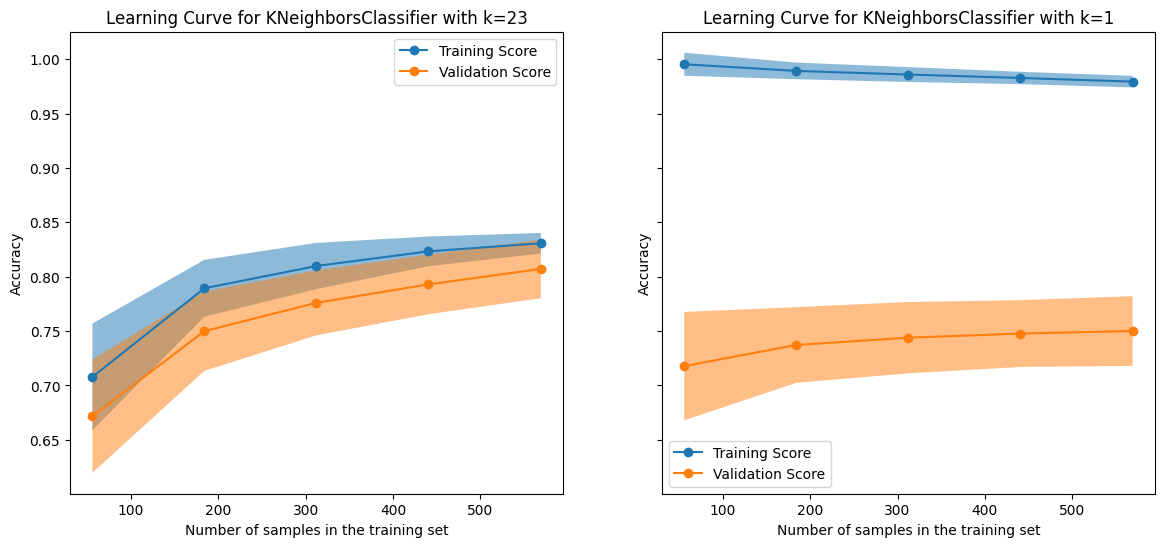

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)

common_params = {
    "X": X_tr,
    "y": y_tr,
    "train_sizes": np.linspace(0.1, 1.0, 5), # 5 different sizes of the training set
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=0), # 50 repetitions of 80-20% cross-validation
    "score_type": "both", # we want to see both training and validation scores
    "n_jobs": -1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "Accuracy",
}

for ax_idx, estimator in enumerate([best_knn.best_estimator_, knn_1_neighbor]):
    LearningCurveDisplay.from_estimator(estimator, **common_params, ax=ax[ax_idx])
    handles, label = ax[ax_idx].get_legend_handles_labels()
    ax[ax_idx].legend(handles[:2], ["Training Score", "Validation Score"])
    ax[ax_idx].set_title(f"Learning Curve for {estimator.__class__.__name__} with k={estimator.n_neighbors}")

plt.show()

**Questions**:
- What can you say about the learning curve of the model with k = 1? Is the model overfitting or underfitting the data?
- What can you say about the learning curve of the model with k = 23? Is the model overfitting or underfitting the data?

**Answers**:
- The learning curve of the model with k = 1 shows that the training score is close to 1, while the validation score is close to 0.7. This means that the model is overfitting the data. The model is learning the training data too well, but it is not generalizing well to new data. Increasing the dataset may help, but from the chart, it seems that the model is not learning the data well. You will probably need much more data to train this model with k = 1.
- The learning curve of the model with k = 23 shows that the training score and the validation score are close to each other. This means that the model is not overfitting or underfitting the data. The model is learning the data well and generalizing well to new data.

### Conclusion Section 3
In this section, we learned how to use the Scikit-learn library to train and fine-tune a machine learning model. In particular, we learned how to use grid search and cross-validation to find the best hyperparameters for the model. We also learned how to plot the learning curve to see if the model is overfitting or underfitting the data.

In the next section, you will perform the final evaluation of the model using on the **test set**. You will compute performance metrics such as the confusion matrix, the accuracy, the precision, the recall and the F1 score.

## 4. Evaluation

We have the best possible model we can fit with the training set (at least in terms of *accuracy*). Now we can evaluate it on the test set. 
This should be the first time we use the test set. 

For the evaluation, we will:
- make the predictions on the test set with the best modelwe have
- plot the confusion matrix
- compute the accuracy, the precision, the recall, and the F1 score
- plot the learning curve (to evaluate possible overfitting or underfitting)

In [71]:
# predictions
y_pred = best_knn.predict(X_te)

In [72]:
# confusion matrix (simple)
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_te, y_pred)
print('Confusion matrix:\n', confusion)

Confusion matrix:
 [[93 12]
 [22 52]]


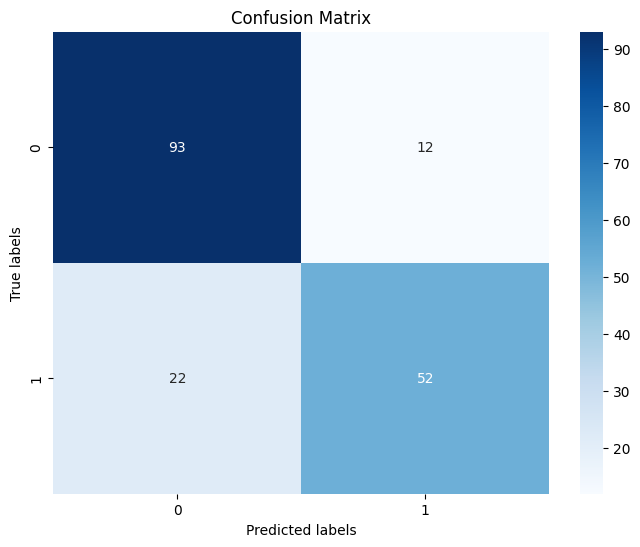

In [73]:
# confusion matrix (fancy)
import seaborn as sns
import matplotlib.pyplot as plt

# we create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


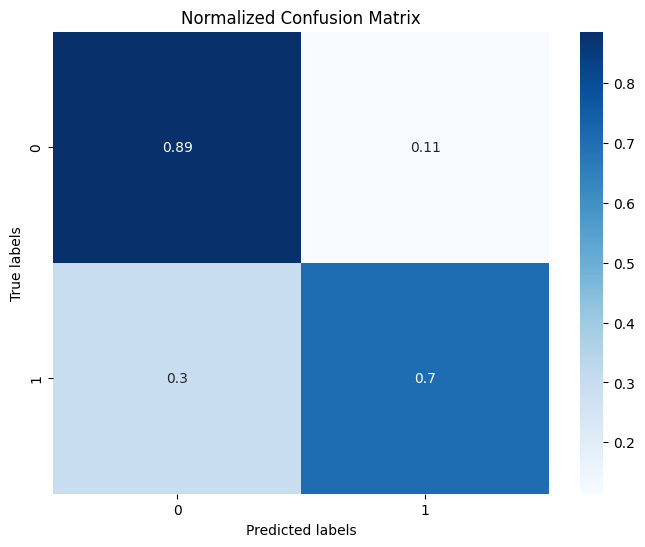

In [74]:
# confusion matrix (fancy and normalized)
confusion_normalized = confusion / confusion.sum(axis=1)[:, np.newaxis]

# we create a heatmap of the normalized confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_normalized, annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Normalized Confusion Matrix')
plt.show()


In [75]:
# classification report
from sklearn.metrics import classification_report
print('Classification report:\n', classification_report(y_te, y_pred))

Classification report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



**Questions**:
- Are you happy with the result? Why?
- The results that you got on the training set are very different from the results on the test set. What does it mean?
- What could you do to improve the model?

**Answers**:
- The results are quite good. We have an accuracy of ~0.81 (in the test set), which means that the model is correct 81% of the time on unseen data. The precision, recall, and F1 score are also good.
- The results on the training set are not very different from the results on the test set. This is not surprising, as we used cross-validation to find the best hyperparameters for the model. In addition, the learning curve did not show overfitting or underfitting. This means that the model is learning the data well and generalizing well to new data.
- To improve the performance, of course, we could try other algorithms. We could also try other preprocessing techniques, such as feature engineering, feature selection, or feature extraction. Finally, we saw in the first part that the dataset is slightly imbalanced. We could try to balance the dataset to see if it improves the performance.

### Conclusion Section 4
In this section, we evaluated the performance of a k-nn model on the test set. We computed metrics such as the confusion matrix, the accuracy, the precision, the recall and the F1 score.

This completes a full Machine Learning workflow. We started from the data exploration, then we prepared the data for the training, we trained and fine-tuned a model, and finally we evaluated the model on the test set. In the next and last section, you will modify the code above to train and evaluate a SVM model.

## 5 Support Vector Machine (SVM)

In this section you will train and evaluate a Support Vector Machine (SVM) model. We suggest that you directly modify the code above to train, fine-tune, and evaluate a SVM model in addition to the k-nn model. In the evaluation section, you can compare the performance of the two models.

We suggest using the [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) class from the Scikit-learn library to train a SVM model. The `SVC` class implements the Support Vector Classification algorithm.

Once implemented and tested, answer the following question below.

**Questions**:
- Which model performs better? (k-nn or SVM)? Why do you think so?
- Which hyperparameters did you tune for the SVM model? What's the best combination of hyperparameters you found?
- Which model is faster to train? (k-nn or SVM)? Why do you think so?
- Discuss the advantages and disadvantages of the two models (k-nn and SVM). Investigate the idea of Lazy learning vs Eager learning.

**Answers**:
- The two models perform similarly. It will be hard with a statistical analysis to say which one is better. In my case, the SVM model performs slightly better than the k-nn model. However, this may not be the case for other datasets. The performance of the models depends on the dataset and the hyperparameters used.
- I tuned the `C` and `kernel` hyperparameters for the SVM model. The best combination of hyperparameters I found is `C=1` and `kernel='rbf'`.
- The k-nn model is faster to train than the SVM model. This is because the k-nn model does not require any training. The SVM model requires solving a quadratic optimization problem, which can be computationally expensive.
- The k-nn model is a lazy learning algorithm, while the SVM model is an eager learning algorithm. Lazy learning algorithms do not require any training and they store the training data. When a new data point is provided, the algorithm uses the training data to make a prediction. Eager learning algorithms, on the other hand, require training and they do not store the training data. When a new data point is provided, the algorithm uses the model learned during training to make a prediction. The advantage of lazy learning algorithms is that they are simple to implement and they can be used for any type of data. The disadvantage of lazy learning algorithms is that they can be computationally expensive when making predictions, especially for large datasets. The advantage of eager learning algorithms is that they can be more accurate than lazy learning algorithms, especially for large datasets. The disadvantage of eager learning algorithms is that they can be computationally expensive to train, especially for large datasets.

### Conclusion Section 5

In this section, you learned how to use the Scikit-learn library to train and evaluate a Support Vector Machine (SVM) model. You also compared the performance of the SVM model with the k-nn model. Now you should have a quite good understanding of the Machine Learning workflow using the Scikit-learn library, in particular for classification tasks.

#### [Optional] Going further - Regression task
In this project, we performed a classification task. However, k-nn and SVM can also be used to perform regression tasks.
We could change the project to a regression task by defining a new target (e.g., the `Age` of the passenger).

Most of the steps are the same, but there are some important differences. For example, in a regression task:
- You need to use other metrics such as the mean squared error (MSE) or the mean absolute error (MAE) score.
- You need to use other classes such as the `KNeighborsRegressor` or the `SVR` class instead of the `KNeighborsClassifier` or the `SVC` class.